# 03 Endogenous Explicit Features

This notebook is the downstream **endogenous explicit feature checkpoint** for the hourly day-ahead market (DAM) forecasting pipeline.

It does **not** redo the raw cleaning stage from `01_da_prices_cleaning_walkthrough.ipynb`.

Instead, it focuses on four downstream tasks:
- validating the already-cleaned hourly DA price series carefully
- making any remaining missing timestamps or missing values explicit on the canonical hourly UTC grid
- building a separate **causal feature-source helper series** for lag-based feature engineering only
- constructing the exact `FS1` endogenous explicit feature pool and its diagnostics before heavier model work starts

Scope boundaries for this notebook:
- only **hourly** DAM forecasting
- no exogenous variables yet
- no Prophet modeling yet
- no heavy walk-forward benchmark yet
- only a very light pipeline smoke test at the end

Later benchmark scripts rebuild their own matrices internally, so this notebook is the transparent inspection checkpoint for the feature layer rather than the only place those matrices can be created.

In [1]:
from datetime import timedelta
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

NOTEBOOK_CWD = Path.cwd()
REPO_ROOT = next(
    path
    for path in [NOTEBOOK_CWD, *NOTEBOOK_CWD.parents]
    if (path / "scripts/Data/02_Forecasting/01_DA_prices").exists()
)
os.chdir(REPO_ROOT)

PACKAGE_ROOT = REPO_ROOT / "scripts/Data/02_Forecasting/01_DA_prices"
if str(PACKAGE_ROOT) not in sys.path:
    sys.path.append(str(PACKAGE_ROOT))

from hourly_da.core.config import HourlyDAPipelineConfig
from hourly_da.core.data_loading import (
    audit_timezone_handling,
    handle_missing_da_prices,
    load_and_validate_da_series,
)
from hourly_da.core.endogenous_features import (
    build_endogenous_explicit_features,
    endogenous_required_history_hours,
    summarize_feature_matrix,
)
from hourly_da.core.methodology import STARTER_ENDOGENOUS_FEATURE_NOTE, feature_stage_policy_frame
from hourly_da.core.storage import create_run_directory, write_csv, write_json
from hourly_da.core.tabular import build_training_data
from hourly_da.notebook_support import apply_notebook_display_defaults

apply_notebook_display_defaults(max_columns=200, width=220)
plt.style.use("default")

config = HourlyDAPipelineConfig(
    input_csv=REPO_ROOT / "data/01_cleaned/Day_ahead_prices/DA_prices/hourly/da_prices_all_regions_hourly.csv",
    raw_root=REPO_ROOT / "data/00_Raw/DA_Prices",
    cleaned_feature_root=REPO_ROOT / "data/01_cleaned",
    output_root=REPO_ROOT / "data/02_Forecasting/01_DA_prices/hourly_da",
)

SAVE_ARTIFACTS = True
RUN_LABEL = "endogenous_explicit_features"
DIAGNOSTIC_WINDOW_DAYS = 14


def first_validation_window(frame: pd.DataFrame, window_days: int = 14) -> pd.DataFrame:
    if "target_delivery_local_date" not in frame.columns:
        return frame.head(window_days * 24).copy()
    start_local = config.validation_start_local
    end_local = start_local + timedelta(days=window_days - 1)
    window = frame[frame["target_delivery_local_date"].between(start_local, end_local)].copy()
    if not window.empty:
        return window
    return frame.head(window_days * 24).copy()


def first_example_day(frame: pd.DataFrame) -> pd.DataFrame:
    if frame.empty:
        return frame.copy()
    first_day = frame["target_delivery_local_date"].min()
    return frame[frame["target_delivery_local_date"] == first_day].copy()


def display_markdown(text: str) -> None:
    display(Markdown(text))

## Notebook roadmap

The notebook follows the same downstream logic that the later forecasting pipeline will rely on:

1. load the cleaned hourly NL DA series
2. re-audit chronology, duplicates, and missingness on that cleaned series
3. build a complete hourly UTC grid
4. create a **causal** feature-source helper series for lag-based feature construction only
5. engineer the exact endogenous explicit feature pool
6. inspect row loss, feature missingness, correlations, and intuitive plots
7. save the feature dataset and metadata in the repo's existing run-artifact structure

The key design principle is **no leakage**:
- all timestamps are stored in UTC internally
- every engineered feature at timestamp `t` uses only information strictly available before `t`
- the helper-series fallback logic never uses future prices
- the observed target column stays untouched, so missing targets remain visible instead of being hidden

In [2]:
display_markdown(f"**FS1 foundation note.** {STARTER_ENDOGENOUS_FEATURE_NOTE}")
display(
    feature_stage_policy_frame()
    .loc[lambda df: df["fs_level"].isin(["FS1", "FS2"])]
    .reset_index(drop=True)
)

**FS1 foundation note.** FS1 is the explicit endogenous feature foundation. The current implementation uses one compact pre-registered endogenous pool: raw lags, lag differences, rolling regime descriptors, and block summary statistics. This keeps the stage interpretable, leakage-safe, and reusable for later FS levels without turning FS1 into an uncontrolled lag buffet.

,fs_level,feature_scope,active_model_families,prophet_policy,shortlisting_policy,tuning_policy,implementation_status,notes
0,FS1,"Explicit endogenous feature foundation only: compact raw lags, lag differences, rolling regime descriptors, and recent block summaries.","lear, xgboost",Prophet is deliberately excluded at FS1.,No shortlisting. LEAR and XGBoost both continue to FS2.,"Fast or coarse validation-only tuning, then freeze settings for FS1.",Active,"FS1 is the explicit endogenous feature foundation. The current implementation uses one compact pre-registered endogenous pool: raw lags, lag differences, rolling regime descriptors, and block summary statistics. This keeps the stage interpretable, leakage-safe, and reusable for later FS levels without turning FS1 into an uncontrolled lag buffet."
1,FS2,FS1 endogenous foundation plus forecast-known calendar and holiday structure.,"lear, xgboost, prophet",Prophet enters for the first time at FS2 because calendar and holiday structure is now meaningful.,First real shortlist point across the FS2 stack.,"First serious validation-only tuning round, then freeze settings for FS2.",Active,LEAR and XGBoost keep using explicit regressors. Prophet joins only here and should remain compact and causal.


## Why this feature pool is deliberately compact

A common first temptation in electricity price forecasting is to throw in a large buffet of lags such as:

`1, 2, 3, 6, 12, 24, 48, 72, 96, 168, 336, ...`

We are **not** doing that here.

Instead, the feature pool is fixed in advance and chosen to represent four distinct roles:

1. **Short-memory persistence**
   The most recent prices still matter.
2. **Daily and weekly anchor structure**
   Electricity prices often depend on yesterday's and last week's comparable hours.
3. **Recent momentum and regime shifts**
   Differences between seasonal anchors can reveal changing conditions.
4. **Recent volatility, spread, and negative-price behaviour**
   A compact set of rolling and block summaries can capture whether the market has recently been calm, turbulent, or negative-price heavy.

This notebook therefore builds one **pre-registered** endogenous feature pool that is compact, interpretable, and fair to reuse later in:
- `FS1` for `LEAR` and `XGBoost`
- `FS2`, where calendar and holiday features are added on top of the same base

## 1. Load and validate the hourly DA series

We start from the existing cleaned hourly DA file for the Dutch market area (`NL`) produced upstream.

Upstream cleaning already handled raw parsing, deduplication, DST treatment, and the missing-datapoint fix.

Even so, we still re-check:
- whether the timestamps parse as UTC
- whether the rows are ordered chronologically
- whether duplicate timestamps exist
- whether expected hourly timestamps are missing
- whether price values themselves are missing

This is important because feature engineering is only trustworthy if the cleaned time axis itself is trustworthy.

In [3]:
validation = load_and_validate_da_series(config)
timezone_audit = audit_timezone_handling(config)
missing = handle_missing_da_prices(validation.source_frame, config)
feature_frame = build_endogenous_explicit_features(missing.canonical_frame, config)
summary = summarize_feature_matrix(feature_frame, config)

print("Validation and feature construction objects created successfully.")

Validation and feature construction objects created successfully.


In [4]:
row_count_table = pd.DataFrame(
    [
        {"stage": "Rows in input CSV", "rows": int(validation.integrity_summary.loc[0, "rows_in_input_csv"])},
        {"stage": "Rows after NL market filter", "rows": int(validation.integrity_summary.loc[0, "rows_after_region_filter"])},
        {
            "stage": "Rows after timestamp parsing and duplicate resolution",
            "rows": int(validation.integrity_summary.loc[0, "rows_after_duplicate_resolution"]),
        },
        {"stage": "Rows on canonical hourly UTC grid", "rows": int(missing.integrity_summary.loc[0, "rows_on_canonical_grid"])},
    ]
)

missing_policy_effect_table = missing.missing_policy_summary.copy()
imputation_method_counts = (
    feature_frame["feature_source_imputation_method"]
    .value_counts(dropna=False)
    .rename_axis("feature_source_imputation_method")
    .reset_index(name="rows")
)

display_markdown("### Data integrity diagnostics")
display(row_count_table)
display(validation.integrity_summary)
display(missing.integrity_summary)

display_markdown("### UTC audit")
display(pd.DataFrame([timezone_audit.to_dict()]))

display_markdown("### Duplicate timestamp details")
if validation.duplicate_details.empty:
    print("No duplicate timestamps were found in the cleaned hourly NL series.")
else:
    display(validation.duplicate_details)

display_markdown("### Missing-data policy summary")
display(missing_policy_effect_table)

display_markdown("### Feature-source imputation method counts")
display(imputation_method_counts)

display_markdown("### Largest explicit gap intervals on the canonical hourly grid")
display(missing.gap_intervals.head(15))

### Data integrity diagnostics

,stage,rows
0,Rows in input CSV,98069
1,Rows after NL market filter,32660
2,Rows after timestamp parsing and duplicate resolution,32660
3,Rows on canonical hourly UTC grid,32855


,market_area,rows_in_input_csv,rows_after_region_filter,rows_with_unparsed_timestamp_dropped,non_monotonic_order_detected,duplicate_timestamp_groups,duplicate_rows_removed,rows_after_duplicate_resolution,missing_price_values_in_observed_rows,min_timestamp_utc,max_timestamp_utc
0,NL,98069,32660,0,False,0,0,32660,0,2021-12-31T23:00:00+00:00,2025-09-30T21:00:00+00:00


,market_area,rows_after_validation,rows_on_canonical_grid,missing_timestamps_count,missing_target_values_count,missing_observations_count,feature_source_imputed_count,feature_source_remaining_missing_count,same_hour_previous_day_count,same_hour_previous_week_count,last_available_observation_count,unfilled_feature_source_count,gap_count,longest_gap_hours,min_timestamp_utc,max_timestamp_utc
0,NL,32660,32855,195,0,195,195,0,194,0,1,0,166,7,2021-12-31T23:00:00+00:00,2025-09-30T21:00:00+00:00


### UTC audit

...

,step_order,policy_step,description,rows_affected
0,1,sort_chronologically,Sort the hourly DA series in ascending UTC order before any validation or filling.,32855
1,2,insert_missing_hourly_timestamps,Reindex to a complete expected hourly UTC grid so missing hours become explicit rows.,195
2,3,mark_originally_missing_values,Keep flags that distinguish missing timestamps from rows whose price value was missing.,195
3,4,same_hour_previous_day,"For feature construction only, first try the value 24 hours earlier on the canonical UTC grid.",194
4,5,same_hour_previous_week,"If the previous-day value is unavailable, try the value 168 hours earlier.",0
5,6,last_available_observation,"If neither seasonal fallback is available, use the last earlier available value as a causal fallback.",1
6,7,leave_target_missing_visible,The observed target column is never overwritten; missing targets remain visible for diagnostics and row filtering.,195
7,8,unfilled_feature_source,"If no earlier causal fallback exists, keep the feature-source value missing and report it explicitly.",0


### Feature-source imputation method counts

,feature_source_imputation_method,rows
0,observed,32660
1,same_hour_previous_day,194
2,last_available_observation,1


### Largest explicit gap intervals on the canonical hourly grid

,gap_start_utc,gap_end_utc,missing_hours,missing_timestamp_count,missing_value_count
0,2024-03-24T08:00:00+00:00,2024-03-24T14:00:00+00:00,7,7,0
1,2024-04-07T01:00:00+00:00,2024-04-07T06:00:00+00:00,6,6,0
2,2025-04-27T00:00:00+00:00,2025-04-27T02:00:00+00:00,3,3,0
3,2025-07-13T11:00:00+00:00,2025-07-13T13:00:00+00:00,3,3,0
4,2022-01-13T18:00:00+00:00,2022-01-13T19:00:00+00:00,2,2,0
5,2022-02-19T11:00:00+00:00,2022-02-19T12:00:00+00:00,2,2,0
6,2022-11-07T00:00:00+00:00,2022-11-07T01:00:00+00:00,2,2,0
7,2023-01-01T07:00:00+00:00,2023-01-01T08:00:00+00:00,2,2,0
8,2023-07-02T12:00:00+00:00,2023-07-02T13:00:00+00:00,2,2,0
9,2024-02-04T04:00:00+00:00,2024-02-04T05:00:00+00:00,2,2,0


### What these diagnostics mean

A few points are worth emphasizing:

- The **UTC audit** confirms that the source timestamps already enter as explicit UTC timestamps. That is important because it means we do not need to guess how to localize ambiguous DST times.
- The **canonical hourly UTC grid** is the reference timeline for the whole feature pipeline. Any missing hour becomes an explicit row instead of silently disappearing.
- The **observed target column** is intentionally kept untouched. If a DA price is truly missing, it remains missing in the target column.
- The **feature-source series** is a separate helper series used only so lag-based features can still be built causally when historical observations are missing.
- This notebook therefore does **not** repeat the upstream raw-data cleaning step. It only adds a leakage-safe helper layer on top of the cleaned target series.

In other words:

- `price_eur_per_mwh` is the truth we score against
- `price_feature_source_eur_per_mwh` is the causal helper series we use for feature construction

## 2. Inspect the cleaned price series and the causal feature-source helper

Before engineering features, it is useful to look at both the cleaned observed target and the helper series derived from it.

We will inspect:
- the full history
- a zoomed-in window from the beginning of the validation period
- the distribution of observed prices versus the causal feature-source series

The selected zoom window is not hand-picked. It is simply the **first 14 local delivery days of the validation period**.

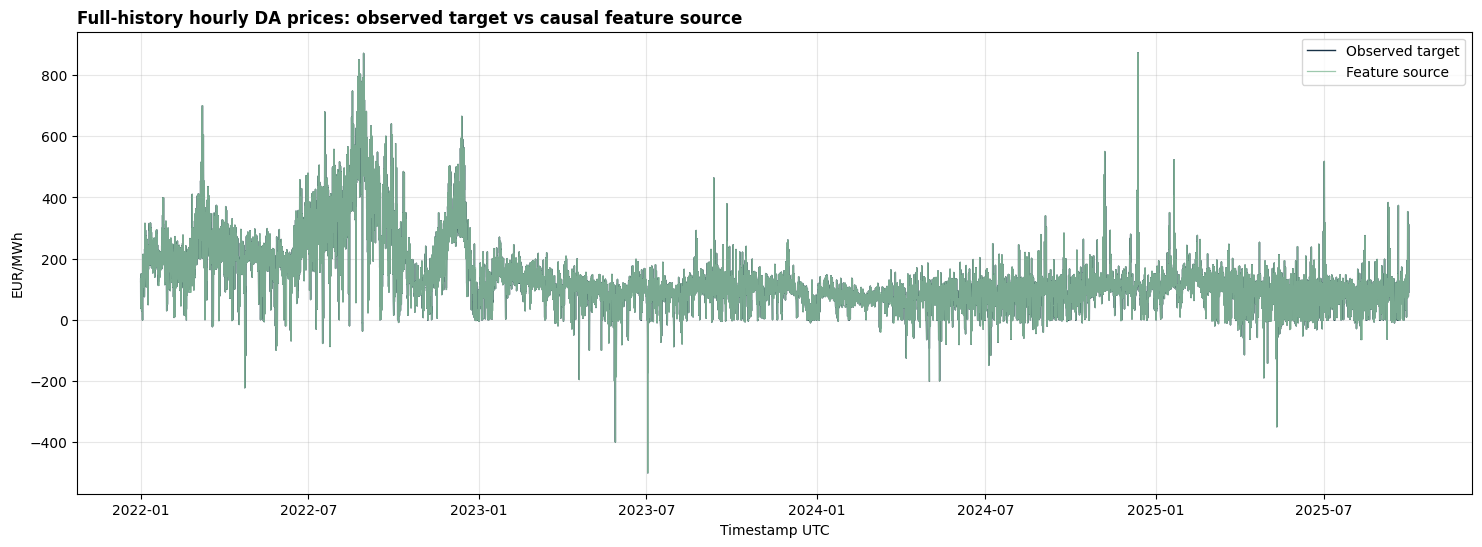

In [5]:
validation_window = first_validation_window(feature_frame, window_days=DIAGNOSTIC_WINDOW_DAYS)

fig, ax = plt.subplots(figsize=(18, 6))
ax.plot(feature_frame[config.timestamp_col], feature_frame[config.target_col], linewidth=1.0, color="#183247", label="Observed target")
ax.plot(
    feature_frame[config.timestamp_col],
    feature_frame[config.feature_source_col],
    linewidth=0.9,
    color="#8cbf9f",
    alpha=0.85,
    label="Feature source",
)
ax.set_title("Full-history hourly DA prices: observed target vs causal feature source", loc="left", fontweight="bold")
ax.set_xlabel("Timestamp UTC")
ax.set_ylabel("EUR/MWh")
ax.grid(alpha=0.3)
ax.legend()
plt.show()

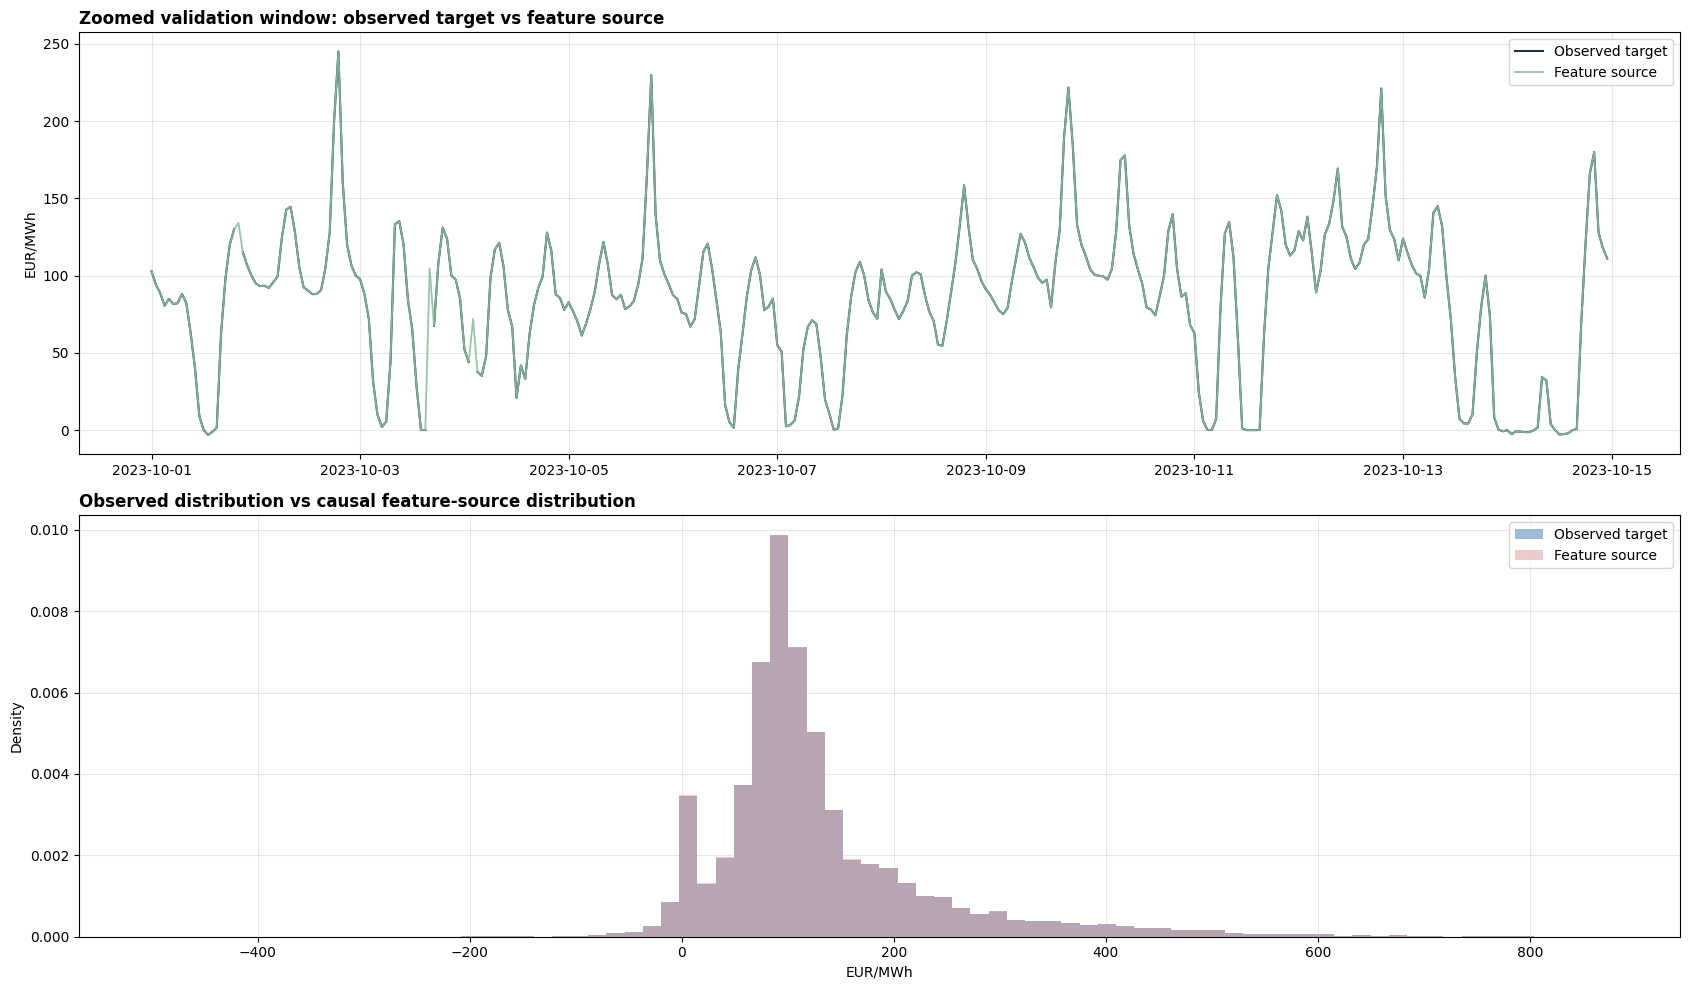

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(17, 10), sharex=False)

axes[0].plot(validation_window["target_timestamp_local"], validation_window[config.target_col], color="#183247", linewidth=1.5, label="Observed target")
axes[0].plot(
    validation_window["target_timestamp_local"],
    validation_window[config.feature_source_col],
    color="#8cbf9f",
    linewidth=1.3,
    alpha=0.9,
    label="Feature source",
)
axes[0].set_title("Zoomed validation window: observed target vs feature source", loc="left", fontweight="bold")
axes[0].set_ylabel("EUR/MWh")
axes[0].grid(alpha=0.3)
axes[0].legend()

observed = feature_frame[config.target_col].dropna().astype(float)
cleaned = feature_frame[config.feature_source_col].dropna().astype(float)
axes[1].hist(observed, bins=80, density=True, alpha=0.60, color="#5f8fbd", label="Observed target")
axes[1].hist(cleaned, bins=80, density=True, alpha=0.45, color="#d88c8a", label="Feature source")
axes[1].set_title("Observed distribution vs causal feature-source distribution", loc="left", fontweight="bold")
axes[1].set_xlabel("EUR/MWh")
axes[1].set_ylabel("Density")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

### Interpreting the plots

The full-history plot shows whether the causal feature-source series is behaving reasonably. In a good setup:

- most of the time, the observed target and feature source lie on top of each other
- the feature source deviates only where the observed target is missing
- there is no suspicious smoothing caused by future-aware interpolation

The distribution plot is also useful. If the causal helper series looked radically different from the observed series, that would be a warning sign. In practice, we expect only a small difference because the missing share is low and the fallback is used only where needed.

## 3. Build the exact endogenous explicit feature pool

We now construct the feature pool for `FS1`.

The exact design is:

**A. Raw lag features**
- `lag_1`, `lag_2`, `lag_24`, `lag_25`, `lag_168`, `lag_169`

**B. Lag-difference / momentum features**
- `diff_1 = y[t-1] - y[t-2]`
- `diff_24 = y[t-24] - y[t-48]`
- `diff_168 = y[t-168] - y[t-336]`
- `cross_season_diff = y[t-24] - y[t-168]`

**C. Strictly causal rolling regime descriptors**
- `roll_mean_24`, `roll_std_24`, `roll_mean_168`, `roll_std_168`

**D. Non-redundant block summary statistics**
- previous-day block `[t-24, t-1]`: `day_min_24`, `day_max_24`, `day_range_24`, `neg_share_24`
- comparable previous-week block `[t-168, t-145]`: `week_min_block`, `week_max_block`, `week_range_block`, `neg_share_week_block`

In [7]:
theoretical_first_usable_timestamp = pd.Timestamp(summary.metadata_summary["theoretical_first_usable_timestamp_utc"])

display_markdown("### Feature catalog")
display(summary.feature_catalog)

display_markdown("### Final feature matrix preview")
preview_columns = [
    config.timestamp_col,
    "target_timestamp_local",
    config.target_col,
    config.feature_source_col,
    "feature_source_imputation_method",
    "lag_1",
    "lag_24",
    "lag_168",
    "diff_24",
    "cross_season_diff",
    "roll_mean_24",
    "roll_std_24",
    "day_range_24",
    "neg_share_24",
    "week_range_block",
    "neg_share_week_block",
    "has_all_endogenous_features",
    "is_usable_for_supervised_learning",
]
display(feature_frame[preview_columns].head(15))

display_markdown("### Missingness per feature")
display(summary.missingness_table)

display_markdown("### Row-loss summary")
display(summary.row_loss_table)

display_markdown("### Metadata summary")
display(pd.DataFrame([summary.metadata_summary]))

print(f"Theoretical first usable timestamp due to lag / window requirements: {theoretical_first_usable_timestamp.isoformat()}")
print(f"Maximum required lookback hours: {endogenous_required_history_hours(config)}")

### Feature catalog

,feature_name,role_group,formula,plain_language_meaning,time_window_used,why_included
0,lag_1,Short-memory persistence,y[t-1],The most recent hourly DA price.,1 hour before t,Captures very short-run persistence.
1,lag_2,Short-memory persistence,y[t-2],The DA price two hours ago.,2 hours before t,Adds one more step of short-run memory without creating a large lag buffet.
2,lag_24,Daily and weekly anchor structure,y[t-24],The price at the same UTC hour one day earlier.,24 hours before t,Anchors the model to yesterday's hourly pattern.
3,lag_25,Daily and weekly anchor structure,y[t-25],The hour just before yesterday's same-hour anchor.,25 hours before t,Adds local context around the daily anchor without opening a very wide lag set.
4,lag_168,Daily and weekly anchor structure,y[t-168],The price at the same UTC hour one week earlier.,168 hours before t,Anchors the model to the comparable hour last week.
5,lag_169,Daily and weekly anchor structure,y[t-169],The hour just before last week's same-hour anchor.,169 hours before t,Adds context around the weekly anchor in a compact way.
6,diff_1,Recent momentum and regime shifts,y[t-1] - y[t-2],The most recent one-hour price change.,Hours t-2 to t-1,Captures immediate momentum or reversal.
7,diff_24,Recent momentum and regime shifts,y[t-24] - y[t-48],How yesterday's same-hour price compares with two days ago.,24 and 48 hours before t,Measures short seasonal acceleration across days.
8,diff_168,Recent momentum and regime shifts,y[t-168] - y[t-336],How last week's same-hour price compares with two weeks ago.,168 and 336 hours before t,Captures slower weekly regime drift.
9,cross_season_diff,Daily and weekly anchor structure,y[t-24] - y[t-168],The gap between yesterday's and last week's same-hour anchors.,24 and 168 hours before t,Shows whether the daily and weekly anchor structures currently disagree.


### Final feature matrix preview

,timestamp_utc,target_timestamp_local,price_eur_per_mwh,price_feature_source_eur_per_mwh,feature_source_imputation_method,lag_1,lag_24,lag_168,diff_24,cross_season_diff,roll_mean_24,roll_std_24,day_range_24,neg_share_24,week_range_block,neg_share_week_block,has_all_endogenous_features,is_usable_for_supervised_learning
0,2021-12-31 23:00:00+00:00,2022-01-01 00:00:00+01:00,124.70,124.70,observed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False
1,2022-01-01 00:00:00+00:00,2022-01-01 01:00:00+01:00,NaN,124.70,last_available_observation,124.70,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False
2,2022-01-01 01:00:00+00:00,2022-01-01 02:00:00+01:00,134.00,134.00,observed,124.70,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False
3,2022-01-01 02:00:00+00:00,2022-01-01 03:00:00+01:00,58.80,58.80,observed,134.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False
4,2022-01-01 03:00:00+00:00,2022-01-01 04:00:00+01:00,37.67,37.67,observed,58.80,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False
5,2022-01-01 04:00:00+00:00,2022-01-01 05:00:00+01:00,39.70,39.70,observed,37.67,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False
6,2022-01-01 05:00:00+00:00,2022-01-01 06:00:00+01:00,40.59,40.59,observed,39.70,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False
7,2022-01-01 06:00:00+00:00,2022-01-01 07:00:00+01:00,43.26,43.26,observed,40.59,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False
8,2022-01-01 07:00:00+00:00,2022-01-01 08:00:00+01:00,49.66,49.66,observed,43.26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False
9,2022-01-01 08:00:00+00:00,2022-01-01 09:00:00+01:00,70.05,70.05,observed,49.66,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False


### Missingness per feature

...

### Row-loss summary

,stage,rows,share_of_total_pct
0,rows_on_canonical_grid,32855,100.000000
1,rows_after_theoretical_lookback_requirement,32519,98.977325
2,rows_with_observed_target,32660,99.406483
3,rows_with_complete_endogenous_features,32519,98.977325
4,rows_usable_for_supervised_learning,32327,98.392939


### Metadata summary

,feature_count,feature_names,theoretical_first_usable_timestamp_utc,endogenous_required_history_hours,total_rows_on_canonical_grid,rows_after_theoretical_lookback,rows_with_observed_target,rows_with_complete_endogenous_features,rows_usable_for_supervised_learning,target_missing_rows,feature_incomplete_rows,rows_by_dataset_split
0,22,"[lag_1, lag_2, lag_24, lag_25, lag_168, lag_169, diff_1, diff_24, diff_168, cross_season_diff, roll_mean_24, roll_std_24, roll_mean_168, roll_std_168, day_min_24, day_max_24, day_range_24, neg_share_24, week_min_block, week_max_block, week_range_block, neg_share_week_block]",2022-01-14T23:00:00+00:00,336,32855,32519,32660,32519,32327,195,336,"{'test': 8760, 'train': 15311, 'validation': 8784}"


Theoretical first usable timestamp due to lag / window requirements: 2022-01-14T23:00:00+00:00
Maximum required lookback hours: 336


### Why the first usable timestamp is not the first timestamp in the file

Some of the engineered features reach quite far back in time:

- `diff_168` needs `y[t-336]`
- `roll_mean_168` and `roll_std_168` need the previous 168 hours
- the comparable previous-week block also depends on a full 24-hour block one week earlier

This means that the first rows of the canonical series **cannot** yet have a complete feature vector. That is normal and expected.

Importantly, the row-loss table makes this transparent rather than hiding it.

In [8]:
example_day = first_example_day(validation_window)

display_markdown("### Example rows for one selected day")
example_columns = [
    config.timestamp_col,
    "target_timestamp_local",
    config.target_col,
    config.feature_source_col,
    "lag_1",
    "lag_2",
    "lag_24",
    "lag_168",
    "diff_1",
    "diff_24",
    "cross_season_diff",
    "roll_mean_24",
    "roll_std_24",
    "day_min_24",
    "day_max_24",
    "day_range_24",
    "neg_share_24",
    "week_min_block",
    "week_max_block",
    "week_range_block",
    "neg_share_week_block",
]
display(example_day[example_columns].reset_index(drop=True))

### Example rows for one selected day

,timestamp_utc,target_timestamp_local,price_eur_per_mwh,price_feature_source_eur_per_mwh,lag_1,lag_2,lag_24,lag_168,diff_1,diff_24,cross_season_diff,roll_mean_24,roll_std_24,day_min_24,day_max_24,day_range_24,neg_share_24,week_min_block,week_max_block,week_range_block,neg_share_week_block
0,2023-09-30 22:00:00+00:00,2023-10-01 00:00:00+02:00,102.73,102.73,101.04,107.40,99.91,98.71,-6.36,-8.59,1.20,91.829583,34.143677,5.00,159.08,154.08,0.000000,-4.20,157.09,161.29,0.166667
1,2023-09-30 23:00:00+00:00,2023-10-01 01:00:00+02:00,94.14,94.14,102.73,101.04,93.64,87.24,1.69,-2.70,6.40,91.947083,34.176119,5.00,159.08,154.08,0.000000,-4.20,157.09,161.29,0.166667
2,2023-10-01 00:00:00+00:00,2023-10-01 02:00:00+02:00,88.60,88.60,94.14,102.73,90.00,77.73,-8.59,3.41,12.27,91.967917,34.177297,5.00,159.08,154.08,0.000000,-4.20,157.09,161.29,0.166667
3,2023-10-01 01:00:00+00:00,2023-10-01 03:00:00+02:00,80.42,80.42,88.60,94.14,88.72,74.20,-5.54,6.55,14.52,91.909583,34.181801,5.00,159.08,154.08,0.000000,-4.20,157.09,161.29,0.166667
4,2023-10-01 02:00:00+00:00,2023-10-01 04:00:00+02:00,84.89,84.89,80.42,88.60,88.28,78.05,-8.18,49.29,10.23,91.563750,34.254233,5.00,159.08,154.08,0.000000,-4.20,157.09,161.29,0.166667
5,2023-10-01 03:00:00+00:00,2023-10-01 05:00:00+02:00,81.54,81.54,84.89,80.42,92.10,82.52,4.47,23.99,9.58,91.422500,34.274466,5.00,159.08,154.08,0.000000,-4.20,157.09,161.29,0.166667
6,2023-10-01 04:00:00+00:00,2023-10-01 06:00:00+02:00,82.12,82.12,81.54,84.89,105.30,87.50,-3.35,0.04,17.80,90.982500,34.330680,5.00,159.08,154.08,0.000000,-4.20,157.09,161.29,0.166667
7,2023-10-01 05:00:00+00:00,2023-10-01 07:00:00+02:00,88.08,88.08,82.12,81.54,109.46,91.00,0.58,-23.46,18.46,90.016667,34.240242,5.00,159.08,154.08,0.000000,-4.20,157.09,161.29,0.166667
8,2023-10-01 06:00:00+00:00,2023-10-01 08:00:00+02:00,82.10,82.10,88.08,82.12,115.00,81.28,5.96,-15.05,33.72,89.125833,34.000074,5.00,159.08,154.08,0.000000,-4.20,157.09,161.29,0.166667
9,2023-10-01 07:00:00+00:00,2023-10-01 09:00:00+02:00,62.73,62.73,82.10,88.08,105.25,59.36,-5.98,-1.57,45.89,87.755000,33.589997,5.00,159.08,154.08,0.000000,-4.20,157.09,161.29,0.166667


### Why the example-day table is useful

The example-day table makes feature engineering less abstract.

Instead of only seeing formulas, you can inspect a concrete day and check whether:
- `lag_24` really looks like “yesterday’s same hour”
- the momentum features move in the expected direction
- rolling means and rolling standard deviations look sensible
- the block summaries are stable across all 24 rows of the selected day

## 4. Relationship diagnostics

Once the feature matrix exists, we want to ask a few practical questions:

- Which features are most strongly associated with the target?
- Which features are highly redundant with each other?
- Do the summary statistics look plausible?

This does **not** mean we are already doing final model selection. It only means we are sanity-checking the feature space.

### Correlation with the target

,feature_name,correlation_with_target
0,lag_1,0.968339
1,lag_2,0.914857
2,lag_24,0.880985
3,roll_mean_24,0.872403
4,lag_25,0.859910
5,day_max_24,0.829270
6,roll_mean_168,0.817257
7,lag_168,0.804441
8,lag_169,0.787201
9,day_min_24,0.743378


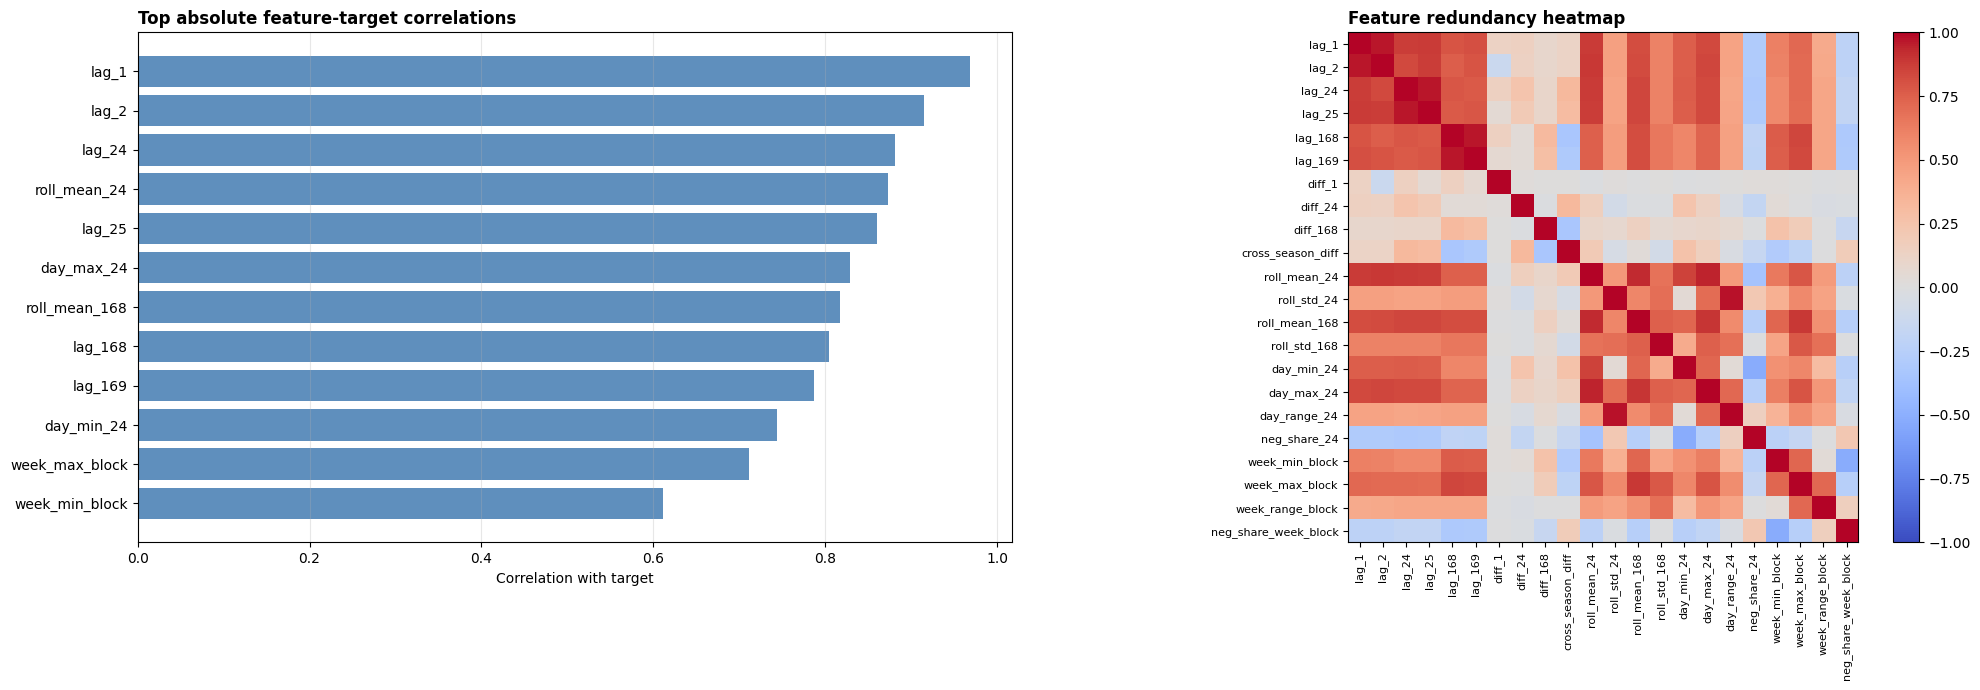

### Summary statistics for all engineered features

,feature_name,mean,std,min,median,max
0,lag_1,128.053112,105.837965,-500.000000,101.855000,872.960000
1,lag_2,128.054026,105.839446,-500.000000,101.860000,872.960000
2,lag_24,128.055454,105.862961,-500.000000,101.860000,872.960000
3,lag_25,128.056530,105.864394,-500.000000,101.870000,872.960000
4,lag_168,128.226122,106.028627,-500.000000,102.000000,872.960000
5,lag_169,128.227514,106.029950,-500.000000,102.000000,872.960000
6,diff_1,-0.000813,27.012075,-272.300000,-1.280000,500.070000
7,diff_24,0.018994,51.720894,-588.750000,-0.200000,537.890000
8,diff_168,-0.371041,66.645193,-725.160000,0.150000,735.060000
9,cross_season_diff,-0.209179,69.430187,-778.500000,0.600000,730.690000


In [9]:
display_markdown("### Correlation with the target")
display(summary.feature_target_correlations)

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

top_corr = summary.feature_target_correlations.head(12).copy()
axes[0].barh(top_corr["feature_name"], top_corr["correlation_with_target"], color="#5f8fbd")
axes[0].invert_yaxis()
axes[0].set_title("Top absolute feature-target correlations", loc="left", fontweight="bold")
axes[0].set_xlabel("Correlation with target")
axes[0].grid(alpha=0.3, axis="x")

heatmap = summary.feature_correlation_matrix.to_numpy(dtype=float)
image = axes[1].imshow(heatmap, cmap="coolwarm", vmin=-1.0, vmax=1.0)
axes[1].set_xticks(range(summary.feature_correlation_matrix.shape[1]))
axes[1].set_xticklabels(summary.feature_correlation_matrix.columns, rotation=90, fontsize=8)
axes[1].set_yticks(range(summary.feature_correlation_matrix.shape[0]))
axes[1].set_yticklabels(summary.feature_correlation_matrix.index, fontsize=8)
axes[1].set_title("Feature redundancy heatmap", loc="left", fontweight="bold")
fig.colorbar(image, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

display_markdown("### Summary statistics for all engineered features")
display(summary.summary_statistics)

### How to read these diagnostics

A few cautions are important:

- High correlation with the target does **not** automatically mean a feature is “best”.
- High correlation between two features does **not** automatically mean one must be deleted.
- The purpose here is not premature feature pruning. It is simply to understand whether the feature design behaves sensibly.

For example:

- strong correlations for `lag_24` or `lag_168` are expected because hourly electricity prices often show clear daily and weekly structure
- strong correlations among `day_min_24`, `day_max_24`, and `day_range_24` are also expected because they summarize the same recent block from different angles

## 5. Visual intuition plots

Feature tables are precise, but plots make the features easier to understand intuitively.

Below we focus on the same validation window and plot:
- the target against `lag_24`
- the target against `roll_mean_24` and `roll_mean_168`
- daily range together with the recent negative-price share

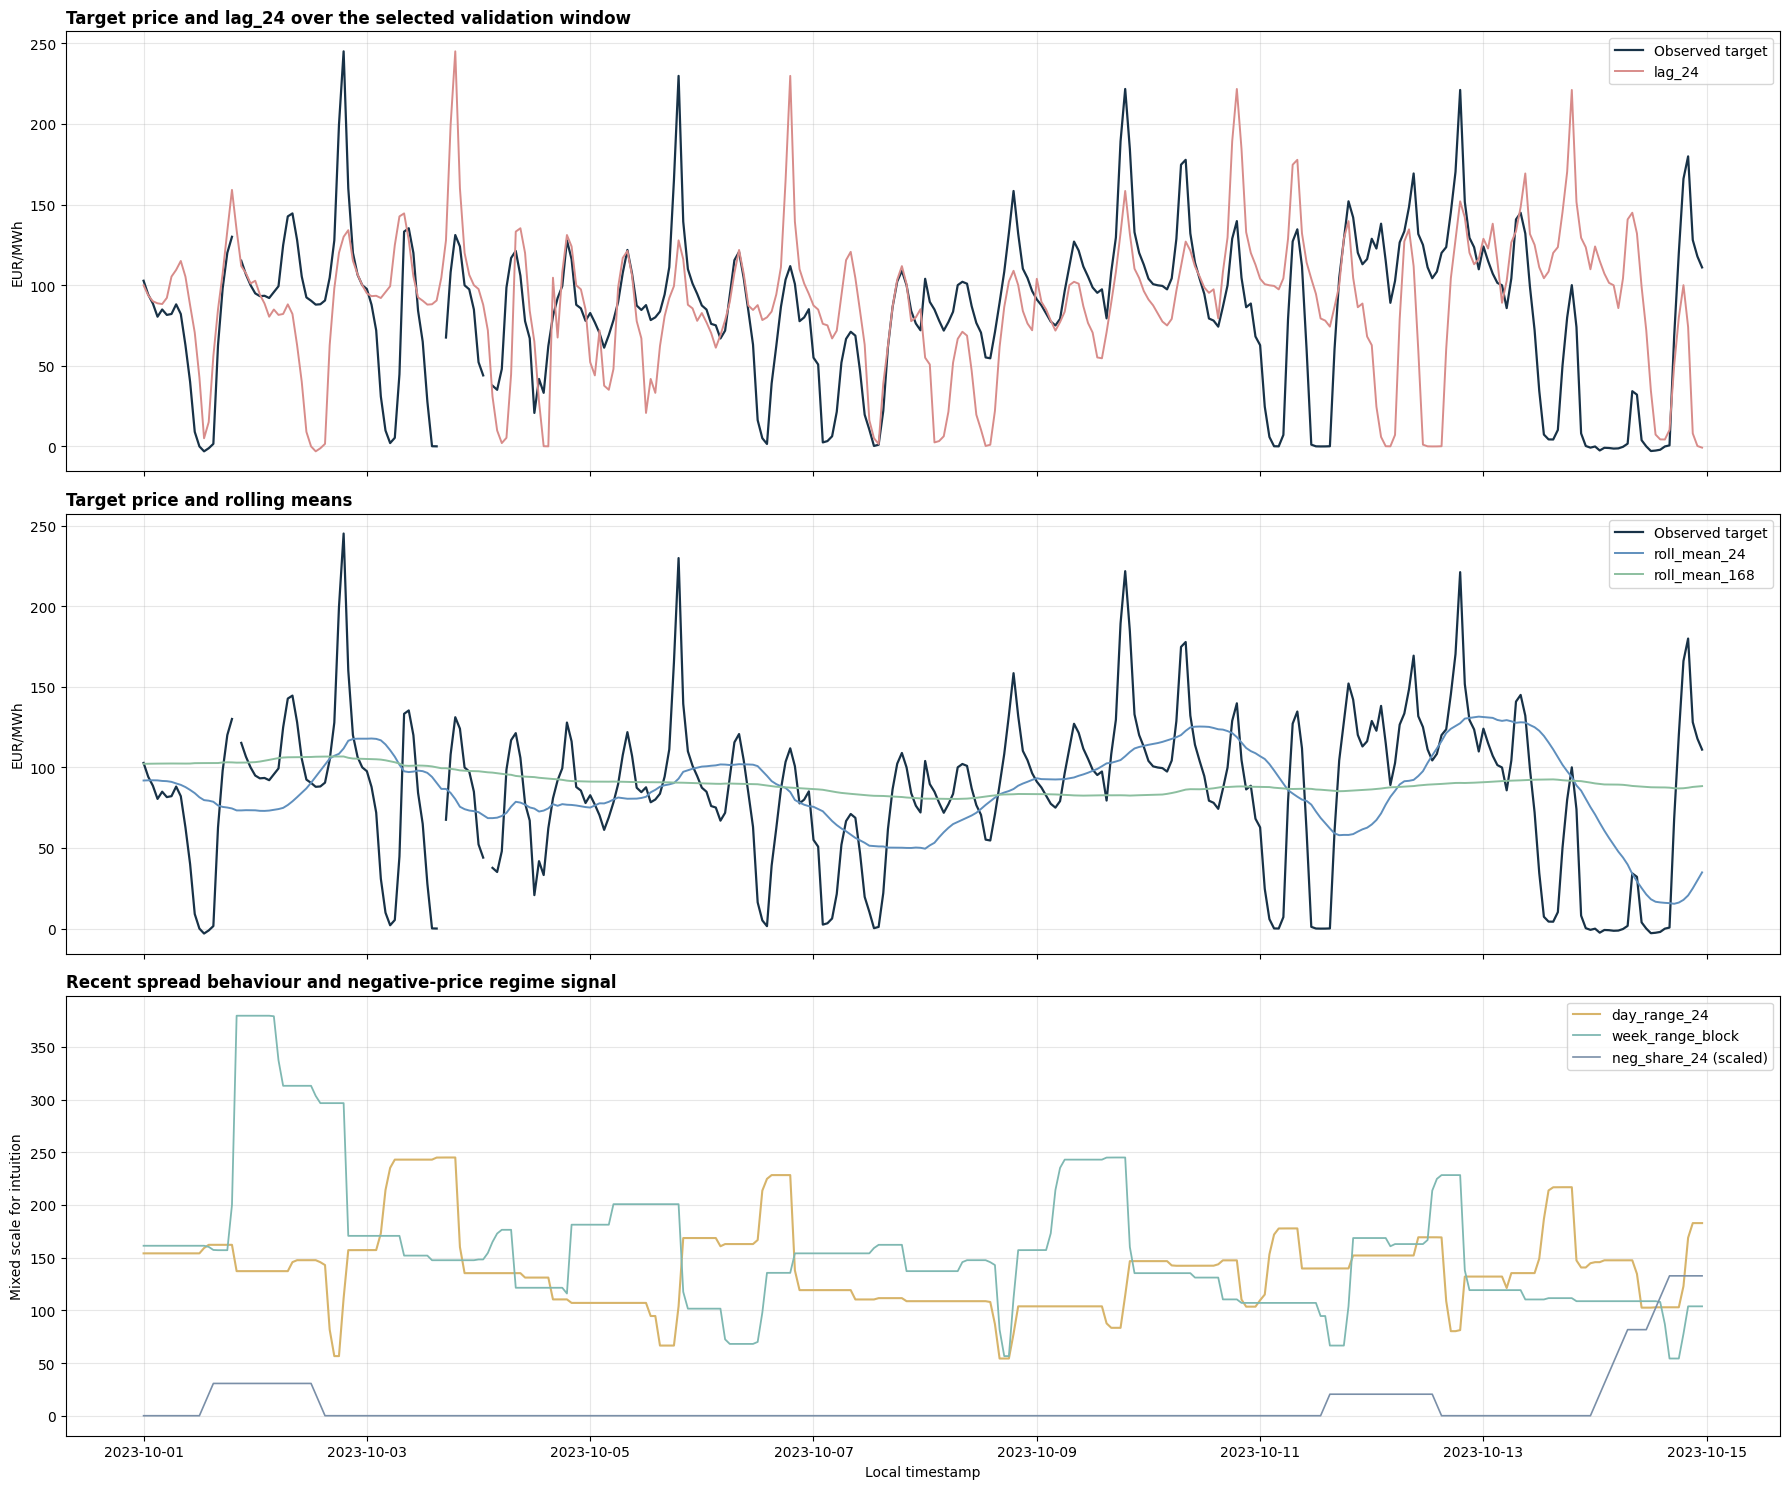

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(18, 15), sharex=True)

axes[0].plot(validation_window["target_timestamp_local"], validation_window[config.target_col], color="#183247", linewidth=1.6, label="Observed target")
axes[0].plot(validation_window["target_timestamp_local"], validation_window["lag_24"], color="#d88c8a", linewidth=1.4, label="lag_24")
axes[0].set_title("Target price and lag_24 over the selected validation window", loc="left", fontweight="bold")
axes[0].set_ylabel("EUR/MWh")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(validation_window["target_timestamp_local"], validation_window[config.target_col], color="#183247", linewidth=1.6, label="Observed target")
axes[1].plot(validation_window["target_timestamp_local"], validation_window["roll_mean_24"], color="#5f8fbd", linewidth=1.4, label="roll_mean_24")
axes[1].plot(validation_window["target_timestamp_local"], validation_window["roll_mean_168"], color="#8cbf9f", linewidth=1.4, label="roll_mean_168")
axes[1].set_title("Target price and rolling means", loc="left", fontweight="bold")
axes[1].set_ylabel("EUR/MWh")
axes[1].grid(alpha=0.3)
axes[1].legend()

axes[2].plot(validation_window["target_timestamp_local"], validation_window["day_range_24"], color="#d7b46a", linewidth=1.5, label="day_range_24")
axes[2].plot(validation_window["target_timestamp_local"], validation_window["week_range_block"], color="#7fb8b2", linewidth=1.3, label="week_range_block")
axes[2].plot(validation_window["target_timestamp_local"], validation_window["neg_share_24"] * validation_window["day_range_24"].max(), color="#7a8fa8", linewidth=1.2, label="neg_share_24 (scaled)")
axes[2].set_title("Recent spread behaviour and negative-price regime signal", loc="left", fontweight="bold")
axes[2].set_xlabel("Local timestamp")
axes[2].set_ylabel("Mixed scale for intuition")
axes[2].grid(alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()

### What to look for in the intuition plots

These plots are useful for answering practical questions such as:

- Does `lag_24` visually move with the target when daily structure is strong?
- Does `roll_mean_24` react more quickly than `roll_mean_168` when the price level shifts?
- Do `day_range_24` and `neg_share_24` spike when the market becomes turbulent or enters a negative-price regime?

If the plots looked random or internally inconsistent, that would be a warning sign that the feature engineering logic was wrong. Here, the purpose is to build confidence before moving on to actual FS1 model training.

## 6. Save the engineered feature dataset and summary artifacts

The repo already uses timestamped run folders under:

`data/02_Forecasting/01_DA_prices/hourly_da/runs/<run_id>/`

To stay consistent with that convention, the notebook can save:
- the final engineered feature matrix
- metadata and audit summaries
- the main diagnostic tables

The cell below uses `SAVE_ARTIFACTS = True` by default because this stage is lightweight and fully reproducible.

In [11]:
if SAVE_ARTIFACTS:
    run_id, run_dir = create_run_directory(config.output_root, RUN_LABEL)

    write_json(run_dir / "config_snapshot.json", config.to_json_dict())
    write_json(run_dir / "timezone_audit.json", timezone_audit.to_dict())
    write_json(run_dir / "feature_metadata_summary.json", summary.metadata_summary)

    write_csv(run_dir / "validated_source_series.csv", validation.source_frame)
    write_csv(run_dir / "validation_integrity_summary.csv", validation.integrity_summary)
    write_csv(run_dir / "duplicate_timestamp_details.csv", validation.duplicate_details)
    write_csv(run_dir / "missing_data_integrity_summary.csv", missing.integrity_summary)
    write_csv(run_dir / "missing_policy_summary.csv", missing.missing_policy_summary)
    write_csv(run_dir / "gap_intervals.csv", missing.gap_intervals)
    write_csv(run_dir / "endogenous_feature_matrix.csv", feature_frame)
    write_csv(run_dir / "feature_catalog.csv", summary.feature_catalog)
    write_csv(run_dir / "feature_missingness.csv", summary.missingness_table)
    write_csv(run_dir / "feature_row_loss.csv", summary.row_loss_table)
    write_csv(run_dir / "feature_summary_statistics.csv", summary.summary_statistics)
    write_csv(run_dir / "feature_target_correlations.csv", summary.feature_target_correlations)
    write_csv(
        run_dir / "feature_correlation_matrix.csv",
        summary.feature_correlation_matrix.reset_index().rename(columns={"index": "feature_name"}),
    )
    write_csv(run_dir / "validation_window_preview.csv", validation_window)
    write_csv(run_dir / "example_day_feature_rows.csv", example_day)

    print(f"Artifacts saved to: {run_dir}")
else:
    print("Artifact saving skipped because SAVE_ARTIFACTS is False.")

Artifacts saved to: C:\Users\marijnvalk\PycharmProjects\Thesis\data\02_Forecasting\01_DA_prices\hourly_da\runs\20260408_153241_endogenous_explicit_features


## 7. Very light smoke test

We still avoid heavy model training here.

However, it is useful to confirm that the engineered features can be handed over cleanly to the later tabular pipeline.

The smoke test below only checks that:
- an `FS1` training matrix can be built
- an `FS2` training matrix can also be built from the same endogenous foundation plus calendar features

No heavy benchmark is executed.

In [12]:
train_history = feature_frame[feature_frame["target_delivery_local_date"] <= config.train_end_local].copy()

fs1_training = build_training_data(
    history=train_history,
    config=config,
    fs_level="FS1",
    history_window_hours=24 * 90,
)
fs2_training = build_training_data(
    history=train_history,
    config=config,
    fs_level="FS2",
    history_window_hours=24 * 90,
)

smoke_test_table = pd.DataFrame(
    [
        {
            "fs_level": "FS1",
            "rows": int(fs1_training.X.shape[0]),
            "columns": int(fs1_training.X.shape[1]),
            "first_feature_columns": ", ".join(fs1_training.feature_columns[:6]),
        },
        {
            "fs_level": "FS2",
            "rows": int(fs2_training.X.shape[0]),
            "columns": int(fs2_training.X.shape[1]),
            "first_feature_columns": ", ".join(fs2_training.feature_columns[:6]),
        },
    ]
)

display(smoke_test_table)
print("Smoke test completed. Feature matrices for FS1 and FS2 can be built successfully.")

,fs_level,rows,columns,first_feature_columns
0,FS1,2155,22,"lag_1, lag_2, lag_24, lag_25, lag_168, lag_169"
1,FS2,2155,27,"lag_1, lag_2, lag_24, lag_25, lag_168, lag_169"


Smoke test completed. Feature matrices for FS1 and FS2 can be built successfully.


## How this feeds into FS1 and FS2

This notebook establishes the reusable endogenous foundation for the next forecasting stages.

**For FS1**
- `LEAR` and `XGBoost` will both use this exact endogenous explicit feature layer
- no exogenous variables are added yet
- this keeps the first model comparison fair and interpretable

**For FS2**
- the same endogenous explicit feature layer is reused
- calendar and Dutch holiday features are added on top
- `Prophet` enters only at this stage

**For FS3 and FS4**
- `FS3` will add causal exogenous feature families to this foundation
- `FS4` can add advanced engineered features on top of the same leakage-safe base

That is exactly why it is worth spending time here on chronology, missing-data handling, and transparent diagnostics first.